# 03 — Análisis de features

El objetivo es evaluar conscientemente las variables originales antes de crear nuevas. El análisis parte de las decisiones consolidadas en el EDA y mantiene separadas la descripción, la selección y las transformaciones posteriores.

## Punto de partida

El modelo principal estimará el riesgo inmediatamente después de que una reserva sea confirmada y registrada. Se excluyen las variables que revelan el resultado y aquellas cuyo valor final puede generarse después de ese momento. Los nulos y casos atípicos se validan, pero todavía no se imputan ni transforman.

## Criterio experimental

Toda decisión basada en rendimiento debe evaluarse dentro de la estrategia de validación definida y sin utilizar el conjunto de evaluación final.

## Configuración y carga reproducible

Se reutilizan las funciones de `src.data` para cargar, integrar y normalizar los archivos. La carga prioriza los CSV locales y utiliza las URL Raw sólo cuando no están disponibles.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import chi2_contingency

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
def find_project_root(start_path=None):
    """Busca la raíz del repositorio a partir del directorio actual."""
    start = Path(start_path or Path.cwd()).resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "data" / "raw").is_dir():
            return candidate

    return None


PROJECT_ROOT = find_project_root()
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "No se encontró la raíz local del proyecto. "
        "Para ejecutar este notebook de forma remota debe estar disponible la carpeta src."
    )

project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
print(f"Raíz del proyecto: {PROJECT_ROOT}")

Raíz del proyecto: C:\Code\Vialesoft\Vialesoft_Devlab\Mini_Proyectos\Machine_Learning\Obligatorio2026


In [3]:
from src.data import (
    combine_hotel_datasets,
    load_csv_with_fallback,
    normalize_text_values,
    split_features_target,
)

H1_URL = "https://raw.githubusercontent.com/Lithium582/Obligatorio2026/refs/heads/main/data/raw/H1.csv"
H2_URL = "https://raw.githubusercontent.com/Lithium582/Obligatorio2026/refs/heads/main/data/raw/H2.csv"

h1_df = load_csv_with_fallback(RAW_DATA_DIR / "H1.csv", H1_URL)
h2_df = load_csv_with_fallback(RAW_DATA_DIR / "H2.csv", H2_URL)
bookings_df = combine_hotel_datasets(h1_df, h2_df)
bookings_df = normalize_text_values(bookings_df, null_labels=("NULL",))

print(f"Dataset integrado: {bookings_df.shape[0]:,} filas y {bookings_df.shape[1]} columnas.")

Dataset integrado: 119,390 filas y 32 columnas.


## Validación de la base analítica

Las comprobaciones siguientes protegen los supuestos establecidos durante el EDA. Si cambia el esquema, aparece un target inválido o surge un nulo en una columna inesperada, el notebook debe informarlo antes de continuar.

In [4]:
TARGET_COLUMN = "IsCanceled"
DIRECT_LEAKAGE_COLUMNS = ["ReservationStatus", "ReservationStatusDate"]
TEMPORALLY_UNAVAILABLE_COLUMNS = ["DepositType"]
POST_CONFIRMATION_COLUMNS = ["AssignedRoomType", "BookingChanges"]
COLUMNS_TO_EXCLUDE = [
    *DIRECT_LEAKAGE_COLUMNS,
    *TEMPORALLY_UNAVAILABLE_COLUMNS,
    *POST_CONFIRMATION_COLUMNS,
]

required_columns = {TARGET_COLUMN, *COLUMNS_TO_EXCLUDE}
missing_required_columns = sorted(required_columns.difference(bookings_df.columns))
if missing_required_columns:
    raise ValueError(f"Faltan columnas requeridas: {missing_required_columns}")

if bookings_df[TARGET_COLUMN].isna().any():
    raise ValueError("La variable objetivo contiene valores nulos.")

observed_target_values = set(bookings_df[TARGET_COLUMN].unique())
if observed_target_values != {0, 1}:
    raise ValueError(
        f"Se esperaban los valores de target {{0, 1}} y se encontraron {observed_target_values}."
    )

expected_rows = len(h1_df) + len(h2_df)
if len(bookings_df) != expected_rows:
    raise ValueError(
        f"La integración produjo {len(bookings_df):,} filas; se esperaban {expected_rows:,}."
    )

print("Esquema, cantidad de filas y variable objetivo validados.")

Esquema, cantidad de filas y variable objetivo validados.


### Validación de nulos conocidos

El EDA encontró nulos únicamente en `Company`, `Agent`, `Country` y `Children`. Se permite que esas columnas conserven nulos para que su tratamiento se implemente más adelante dentro del pipeline. Cualquier columna nula adicional se considera un cambio inesperado.

In [5]:
EXPECTED_NULL_COLUMNS = {"Company", "Agent", "Country", "Children"}
null_counts = bookings_df.isna().sum()
observed_null_columns = set(null_counts[null_counts.gt(0)].index)
unexpected_null_columns = sorted(observed_null_columns - EXPECTED_NULL_COLUMNS)

if unexpected_null_columns:
    raise ValueError(
        f"Aparecieron nulos en columnas no previstas: {unexpected_null_columns}"
    )

null_validation_summary = pd.DataFrame(
    {
        "null_rows": null_counts.loc[sorted(EXPECTED_NULL_COLUMNS)],
    }
)
null_validation_summary["null_percentage"] = (
    null_validation_summary["null_rows"] / len(bookings_df) * 100
)
display(null_validation_summary.sort_values("null_rows", ascending=False))
print("No se encontraron nulos en columnas inesperadas.")

,null_rows,null_percentage
Company,112593,94.306893
Agent,16340,13.686238
Country,488,0.408744
Children,4,0.003350


No se encontraron nulos en columnas inesperadas.


## Exclusiones definidas antes del análisis

Estas columnas no se descartan por una asociación estadística débil, sino porque no son admisibles para el momento de predicción. Se eliminan sólo de `X`; el dataset integrado se conserva intacto para auditoría.

In [6]:
exclusion_summary = pd.DataFrame(
    [
        {
            "column": "ReservationStatus",
            "reason": "Describe el desenlace y determina directamente IsCanceled.",
        },
        {
            "column": "ReservationStatusDate",
            "reason": "Registra la fecha en la que se produjo el desenlace.",
        },
        {
            "column": "DepositType",
            "reason": "Se deriva de pagos acumulados antes de la llegada o cancelación y no está disponible de forma consistente al confirmar.",
        },
        {
            "column": "AssignedRoomType",
            "reason": "La asignación final puede ocurrir después de confirmar la reserva.",
        },
        {
            "column": "BookingChanges",
            "reason": "Acumula modificaciones posteriores a la confirmación.",
        },
    ]
)
display(exclusion_summary)

,column,reason
0,ReservationStatus,Describe el desenlace y determina directamente...
1,ReservationStatusDate,Registra la fecha en la que se produjo el dese...
2,DepositType,Se deriva de pagos acumulados antes de la lleg...
3,AssignedRoomType,La asignación final puede ocurrir después de c...
4,BookingChanges,Acumula modificaciones posteriores a la confir...


In [7]:
X_candidates, y = split_features_target(
    bookings_df,
    target_col=TARGET_COLUMN,
    columns_to_drop=COLUMNS_TO_EXCLUDE,
)

remaining_excluded_columns = sorted(
    set(COLUMNS_TO_EXCLUDE).intersection(X_candidates.columns)
)
if remaining_excluded_columns:
    raise ValueError(
        f"Las columnas excluidas continúan en X: {remaining_excluded_columns}"
    )

if TARGET_COLUMN in X_candidates.columns:
    raise ValueError("La variable objetivo continúa presente en X.")

print(f"Features candidatas: {X_candidates.shape[1]}")
display(pd.DataFrame({"feature": X_candidates.columns}))

Features candidatas: 26


,feature
0,HotelType
1,LeadTime
2,ArrivalDateYear
3,ArrivalDateMonth
4,ArrivalDateWeekNumber
5,ArrivalDateDayOfMonth
6,StaysInWeekendNights
7,StaysInWeekNights
8,Adults
9,Children


La base de Feature Analysis conserva una fila por reserva y todas las variables admisibles después de la confirmación. Los nulos conocidos permanecen sin imputar y los casos atípicos no se alteran. El próximo paso será clasificar las features por significado —binarias, categóricas, identificadores, calendario, conteos e importes— antes de medir su relación con el target.

## Clasificación semántica de las features

El `dtype` describe cómo pandas almacena una columna, pero no necesariamente cómo debe analizarse. Por ejemplo, `Agent` y `Company` son identificadores aunque estén representados como texto, mientras que el año y la semana son números con significado temporal. Cada feature se asigna a un único grupo semántico.

In [8]:
FEATURE_GROUPS = {
    "Binary indicator": [
        "IsRepeatedGuest",
    ],
    "Nominal categorical": [
        "HotelType",
        "Meal",
        "Country",
        "MarketSegment",
        "DistributionChannel",
        "ReservedRoomType",
        "CustomerType",
    ],
    "Categorical identifier": [
        "Agent",
        "Company",
    ],
    "Calendar": [
        "ArrivalDateYear",
        "ArrivalDateMonth",
        "ArrivalDateWeekNumber",
        "ArrivalDateDayOfMonth",
    ],
    "Duration": [
        "LeadTime",
        "StaysInWeekendNights",
        "StaysInWeekNights",
        "DaysInWaitingList",
    ],
    "Count": [
        "Adults",
        "Children",
        "Babies",
        "PreviousCancellations",
        "PreviousBookingsNotCanceled",
        "RequiredCarParkingSpaces",
        "TotalOfSpecialRequests",
    ],
    "Monetary continuous": [
        "ADR",
    ],
}

FEATURE_GROUP_DESCRIPTIONS = {
    "Binary indicator": "Indicador con dos estados; se interpreta como categoría binaria.",
    "Nominal categorical": "Categorías sin distancia ni orden numérico inherente.",
    "Categorical identifier": "Códigos de entidad; la magnitud del identificador no tiene significado.",
    "Calendar": "Componentes temporales con orden y, en algunos casos, comportamiento cíclico.",
    "Duration": "Cantidades de tiempo no negativas y potencialmente asimétricas.",
    "Count": "Conteos discretos no negativos, frecuentemente concentrados en cero.",
    "Monetary continuous": "Importe continuo sensible a escala y valores extremos.",
}

### Validación de cobertura y exclusividad

La clasificación debe cubrir exactamente las columnas de `X_candidates`. Una feature omitida, duplicada o inexistente invalida el catálogo y detiene el análisis.

In [9]:
classified_features = [
    feature
    for features in FEATURE_GROUPS.values()
    for feature in features
]
classified_feature_set = set(classified_features)
candidate_feature_set = set(X_candidates.columns)

duplicated_classifications = sorted(
    {feature for feature in classified_features if classified_features.count(feature) > 1}
)
unclassified_features = sorted(candidate_feature_set - classified_feature_set)
unknown_classified_features = sorted(classified_feature_set - candidate_feature_set)

if duplicated_classifications:
    raise ValueError(
        f"Features clasificadas más de una vez: {duplicated_classifications}"
    )
if unclassified_features:
    raise ValueError(f"Features sin clasificación: {unclassified_features}")
if unknown_classified_features:
    raise ValueError(
        f"La clasificación contiene columnas inexistentes: {unknown_classified_features}"
    )

print(
    f"Clasificación validada: {len(classified_features)} features, "
    f"{len(FEATURE_GROUPS)} grupos y ninguna superposición."
)

Clasificación validada: 26 features, 7 grupos y ninguna superposición.


### Catálogo de features

El catálogo combina la clasificación conceptual con el tipo físico, la cardinalidad y los nulos observados. La columna `initial_analysis` indica cómo se estudiará cada grupo, pero no fija todavía una transformación de modelado.

In [10]:
GROUP_ANALYSIS_STRATEGY = {
    "Binary indicator": "Compare cancellation rates between both states.",
    "Nominal categorical": "Compare category frequencies and cancellation rates; quantify association.",
    "Categorical identifier": "Review cardinality, frequency, unseen-category risk and association without ordinal interpretation.",
    "Calendar": "Study temporal order, seasonality and possible cyclical representation.",
    "Duration": "Compare distributions by target and evaluate skewness or robust transformations.",
    "Count": "Compare discrete distributions and the meaning of zero versus positive values.",
    "Monetary continuous": "Compare distributions by target and evaluate sensitivity to extreme values.",
}

feature_catalog_records = []
for group, features in FEATURE_GROUPS.items():
    for feature in features:
        feature_catalog_records.append(
            {
                "feature": feature,
                "semantic_group": group,
                "dtype": str(X_candidates[feature].dtype),
                "unique_values": X_candidates[feature].nunique(dropna=True),
                "null_rows": X_candidates[feature].isna().sum(),
                "null_percentage": X_candidates[feature].isna().mean() * 100,
                "initial_analysis": GROUP_ANALYSIS_STRATEGY[group],
            }
        )

feature_catalog = pd.DataFrame(feature_catalog_records)
display(feature_catalog)

,feature,semantic_group,dtype,unique_values,null_rows,null_percentage,initial_analysis
0,IsRepeatedGuest,Binary indicator,int64,2,0,0.000000,Compare cancellation rates between both states.
1,HotelType,Nominal categorical,str,2,0,0.000000,Compare category frequencies and cancellation ...
2,Meal,Nominal categorical,str,5,0,0.000000,Compare category frequencies and cancellation ...
3,Country,Nominal categorical,str,177,488,0.408744,Compare category frequencies and cancellation ...
4,MarketSegment,Nominal categorical,str,8,0,0.000000,Compare category frequencies and cancellation ...
5,DistributionChannel,Nominal categorical,str,5,0,0.000000,Compare category frequencies and cancellation ...
6,ReservedRoomType,Nominal categorical,str,10,0,0.000000,Compare category frequencies and cancellation ...
7,CustomerType,Nominal categorical,str,4,0,0.000000,Compare category frequencies and cancellation ...
8,Agent,Categorical identifier,str,333,16340,13.686238,"Review cardinality, frequency, unseen-category..."
9,Company,Categorical identifier,str,352,112593,94.306893,"Review cardinality, frequency, unseen-category..."


In [11]:
semantic_group_summary = (
    feature_catalog.groupby("semantic_group", sort=False)
    .agg(
        feature_count=("feature", "size"),
        features=("feature", lambda values: list(values)),
        maximum_cardinality=("unique_values", "max"),
        features_with_nulls=("null_rows", lambda values: values.gt(0).sum()),
    )
    .reset_index()
)
semantic_group_summary["description"] = semantic_group_summary[
    "semantic_group"
].map(FEATURE_GROUP_DESCRIPTIONS)
display(semantic_group_summary)

,semantic_group,feature_count,features,maximum_cardinality,features_with_nulls,description
0,Binary indicator,1,[IsRepeatedGuest],2,0,Indicador con dos estados; se interpreta como ...
1,Nominal categorical,7,"[HotelType, Meal, Country, MarketSegment, Dist...",177,1,Categorías sin distancia ni orden numérico inh...
2,Categorical identifier,2,"[Agent, Company]",352,2,Códigos de entidad; la magnitud del identifica...
3,Calendar,4,"[ArrivalDateYear, ArrivalDateMonth, ArrivalDat...",53,0,"Componentes temporales con orden y, en algunos..."
4,Duration,4,"[LeadTime, StaysInWeekendNights, StaysInWeekNi...",479,0,Cantidades de tiempo no negativas y potencialm...
5,Count,7,"[Adults, Children, Babies, PreviousCancellatio...",73,1,"Conteos discretos no negativos, frecuentemente..."
6,Monetary continuous,1,[ADR],8879,0,Importe continuo sensible a escala y valores e...


Esta clasificación evita dos errores frecuentes: tratar los identificadores de agencia y empresa como cantidades numéricas, y asumir que todos los enteros deben procesarse de la misma manera. Las estrategias definitivas de imputación y codificación se decidirán después de estudiar cada grupo y deberán implementarse dentro de los pipelines para evitar contaminación entre entrenamiento y validación.

## Asociación de variables categóricas con el target

Para variables categóricas no corresponde calcular una correlación de Pearson a partir de códigos arbitrarios. Se utilizan tablas de contingencia, tasas de cancelación y V de Cramér corregida por sesgo. La prueba chi-cuadrado informa si existe evidencia de dependencia, mientras que V de Cramér cuantifica su magnitud en una escala entre cero y uno.

### Tratamiento diagnóstico de categorías infrecuentes

Las categorías con menos de 100 filas se agrupan temporalmente bajo una etiqueta común únicamente para calcular las tablas de contingencia. Esto reduce celdas con frecuencias esperadas demasiado pequeñas, especialmente en `Country`. La operación no modifica `X_candidates` ni constituye todavía una decisión de codificación. Los nulos se representan explícitamente como `Missing`.

In [12]:
MIN_CATEGORY_ROWS_FOR_ASSOCIATION = 100
CATEGORICAL_ASSOCIATION_FEATURES = [
    *FEATURE_GROUPS["Binary indicator"],
    *FEATURE_GROUPS["Nominal categorical"],
]


def prepare_categorical_for_association(
    series,
    minimum_rows=MIN_CATEGORY_ROWS_FOR_ASSOCIATION,
):
    """Representa nulos y agrupa categorías infrecuentes para el diagnóstico."""
    prepared = series.astype("string").fillna("Missing")
    category_counts = prepared.value_counts(dropna=False)
    rare_categories = category_counts.loc[category_counts.lt(minimum_rows)].index
    return prepared.mask(
        prepared.isin(rare_categories),
        f"Other (<{minimum_rows} rows)",
    )


def corrected_cramers_v(contingency_table):
    """Calcula V de Cramér con corrección de sesgo."""
    chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
        contingency_table
    )
    observations = contingency_table.to_numpy().sum()
    rows, columns = contingency_table.shape
    phi_squared = chi2 / observations
    corrected_phi_squared = max(
        0,
        phi_squared - ((columns - 1) * (rows - 1)) / (observations - 1),
    )
    corrected_rows = rows - ((rows - 1) ** 2) / (observations - 1)
    corrected_columns = columns - ((columns - 1) ** 2) / (observations - 1)
    denominator = min(corrected_columns - 1, corrected_rows - 1)
    cramers_v = (
        np.sqrt(corrected_phi_squared / denominator)
        if denominator > 0
        else 0.0
    )
    return {
        "chi2": chi2,
        "p_value": p_value,
        "degrees_of_freedom": degrees_of_freedom,
        "cramers_v": cramers_v,
        "minimum_expected_frequency": expected.min(),
        "expected_cells_below_5": (expected < 5).sum(),
    }

In [13]:
categorical_association_records = []
prepared_categorical_features = {}

for feature in CATEGORICAL_ASSOCIATION_FEATURES:
    prepared_feature = prepare_categorical_for_association(X_candidates[feature])
    prepared_categorical_features[feature] = prepared_feature
    contingency_table = pd.crosstab(prepared_feature, y)
    association = corrected_cramers_v(contingency_table)

    categorical_association_records.append(
        {
            "feature": feature,
            "raw_categories": X_candidates[feature].nunique(dropna=True),
            "analyzed_categories": prepared_feature.nunique(dropna=False),
            **association,
        }
    )

categorical_association_summary = (
    pd.DataFrame(categorical_association_records)
    .sort_values("cramers_v", ascending=False)
    .reset_index(drop=True)
)
display(categorical_association_summary.round(5))

,feature,raw_categories,analyzed_categories,chi2,p_value,degrees_of_freedom,cramers_v,minimum_expected_frequency,expected_cells_below_5
0,Country,177,40,15013.75245,0.0,39,0.35416,37.04163,0
1,MarketSegment,8,8,8497.22409,0.0,7,0.26667,0.74083,2
2,DistributionChannel,5,5,3745.79412,0.0,4,0.17703,1.85208,2
3,HotelType,2,2,2224.92490,0.0,1,0.13648,14838.87629,0
4,CustomerType,4,4,2222.50416,0.0,3,0.13635,213.73020,0
5,IsRepeatedGuest,2,2,857.40632,0.0,1,0.08469,1411.28604,0
6,ReservedRoomType,10,9,640.21196,0.0,8,0.07277,6.66749,0
7,Meal,5,5,304.23618,0.0,4,0.05015,295.59219,0


### Frecuencia y tasa de cancelación por categoría

Las tasas se comparan con el promedio global. Para features de alta cardinalidad se muestran las quince categorías más frecuentes y hasta cinco categorías adicionales con las mayores tasas entre aquellas que poseen al menos 100 filas. De esta forma se evita interpretar porcentajes extremos sustentados en una o dos reservas.

In [14]:
global_cancellation_rate = y.mean()
categorical_rate_tables = {}

for feature in CATEGORICAL_ASSOCIATION_FEATURES:
    analysis_frame = pd.DataFrame(
        {
            "category": X_candidates[feature].astype("string").fillna("Missing"),
            "IsCanceled": y,
        }
    )
    category_rates = (
        analysis_frame.groupby("category", dropna=False)
        .agg(
            rows=("IsCanceled", "size"),
            cancellations=("IsCanceled", "sum"),
            cancellation_rate=("IsCanceled", "mean"),
        )
        .reset_index()
    )
    category_rates["dataset_percentage"] = (
        category_rates["rows"] / len(X_candidates) * 100
    )
    category_rates["difference_from_global_pp"] = (
        category_rates["cancellation_rate"] - global_cancellation_rate
    ) * 100
    categorical_rate_tables[feature] = category_rates

    if len(category_rates) <= 20:
        displayed_rates = category_rates.sort_values(
            "cancellation_rate", ascending=False
        )
    else:
        most_frequent = category_rates.nlargest(15, "rows")
        highest_supported_rates = (
            category_rates.loc[category_rates["rows"].ge(MIN_CATEGORY_ROWS_FOR_ASSOCIATION)]
            .nlargest(5, "cancellation_rate")
        )
        displayed_rates = (
            pd.concat([most_frequent, highest_supported_rates])
            .drop_duplicates(subset="category")
            .sort_values("rows", ascending=False)
        )

    print(feature)
    display(displayed_rates.round(4))

IsRepeatedGuest


,category,rows,cancellations,cancellation_rate,dataset_percentage,difference_from_global_pp
0,0,115580,43672,0.3779,96.8088,0.7435
1,1,3810,552,0.1449,3.1912,-22.5534


HotelType


,category,rows,cancellations,cancellation_rate,dataset_percentage,difference_from_global_pp
0,City Hotel,79330,33102,0.4173,66.4461,4.6853
1,Resort Hotel,40060,11122,0.2776,33.5539,-9.2783


Meal


...

,category,rows,cancellations,cancellation_rate,dataset_percentage,difference_from_global_pp
4,Undefined,5,4,0.8000,0.0042,42.9584
3,TA/TO,97870,40152,0.4103,81.9750,3.9842
0,Corporate,6677,1474,0.2208,5.5926,-14.9658
2,GDS,193,37,0.1917,0.1617,-17.8706
1,Direct,14645,2557,0.1746,12.2665,-19.5817


ReservedRoomType


,category,rows,cancellations,cancellation_rate,dataset_percentage,difference_from_global_pp
9,P,12,12,1.0000,0.0101,62.9584
7,H,601,245,0.4077,0.5034,3.7238
0,A,85994,33630,0.3911,72.0278,2.0658
6,G,2094,763,0.3644,1.7539,-0.6042
8,L,6,2,0.3333,0.0050,-3.7083
2,C,932,308,0.3305,0.7806,-3.9944
1,B,1118,368,0.3292,0.9364,-4.1257
3,D,19201,6102,0.3178,16.0826,-5.2620
5,F,2897,880,0.3038,2.4265,-6.6654
4,E,6535,1914,0.2929,5.4737,-7.7532


CustomerType


,category,rows,cancellations,cancellation_rate,dataset_percentage,difference_from_global_pp
2,Transient,89613,36514,0.4075,75.0591,3.7047
0,Contract,4076,1262,0.3096,3.4140,-6.0799
3,Transient-Party,25124,6389,0.2543,21.0436,-11.6118
1,Group,577,59,0.1023,0.4833,-26.8163


### Comparación del tamaño de asociación

La gráfica ordena las variables por V de Cramér. El valor permite comparar su asociación marginal con el target, pero no mide causalidad ni garantiza que una feature mejore un modelo multivariado.

Gráfica guardada en: C:\Code\Vialesoft\Vialesoft_Devlab\Mini_Proyectos\Machine_Learning\Obligatorio2026\outputs\figures\feature_analysis_categorical_association.png


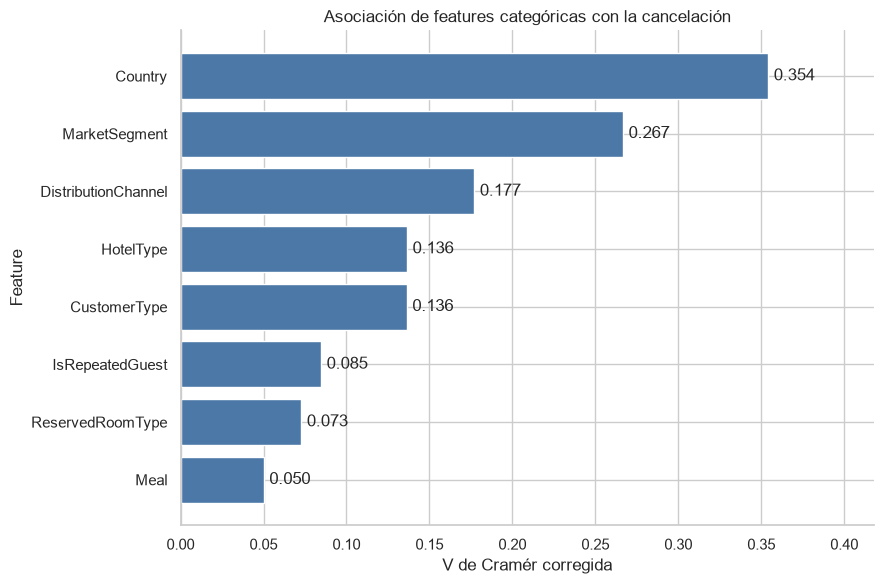

In [15]:
plot_data = categorical_association_summary.sort_values("cramers_v")
figure, axis = plt.subplots(figsize=(9, 6))
bars = axis.barh(
    plot_data["feature"],
    plot_data["cramers_v"],
    color="#4C78A8",
)
axis.bar_label(bars, fmt="%.3f", padding=4)
axis.set_title("Asociación de features categóricas con la cancelación")
axis.set_xlabel("V de Cramér corregida")
axis.set_ylabel("Feature")
axis.set_xlim(0, max(plot_data["cramers_v"].max() * 1.18, 0.05))
sns.despine(ax=axis)
figure.tight_layout()

if PROJECT_ROOT is not None:
    figures_dir = PROJECT_ROOT / "outputs" / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)
    categorical_association_path = (
        figures_dir / "feature_analysis_categorical_association.png"
    )
    figure.savefig(
        categorical_association_path, dpi=300, bbox_inches="tight"
    )
    print(f"Gráfica guardada en: {categorical_association_path}")

plt.show()

Los resultados de este bloque describen asociaciones marginales. Una relación pequeña no implica que la variable sea inútil: puede aportar información mediante interacciones o al controlar por otras features. Del mismo modo, una asociación grande puede reflejar segmentos comerciales o políticas del hotel y debe comprobarse dentro de la validación.

## Análisis condicionado de las asociaciones categóricas principales

`DepositType`, `Country` y `MarketSegment` presentan las mayores asociaciones marginales. Antes de considerarlas señales independientes se estudia si sus tasas están condicionadas por el hotel, los bloques repetidos o el peso de combinaciones exactas.

### Precaución temporal sobre `DepositType`

El nombre puede confundirse con la política contractual de una tarifa. En este dataset la variable fue construida a partir de pagos identificados antes de la llegada o cancelación: `Non Refund` indica que los pagos alcanzaron o superaron el costo total, `Refundable` que existió un pago parcial y `No Deposit` que no se encontraron pagos. Por tanto, el valor puede consolidar transacciones posteriores a la confirmación y no se considera automáticamente disponible en el momento principal de predicción. La definición original puede consultarse en [Hotel booking demand datasets](https://pmc.ncbi.nlm.nih.gov/articles/PMC6297060/).

In [16]:
confirmed_signature_ids = X_candidates.groupby(
    X_candidates.columns.tolist(),
    dropna=False,
    sort=False,
).ngroup()
confirmed_signature_sizes = confirmed_signature_ids.map(
    confirmed_signature_ids.value_counts()
)

categorical_context_df = X_candidates.assign(
    DepositType=bookings_df["DepositType"],
    IsCanceled=y,
    RepetitionStatus=np.where(
        confirmed_signature_sizes.gt(1),
        "Repeated confirmed signature",
        "Unique confirmed signature",
    ),
    ConfirmedSignatureSize=confirmed_signature_sizes,
)
categorical_context_df["CountryScope"] = np.select(
    [
        categorical_context_df["Country"].isna(),
        categorical_context_df["Country"].eq("PRT"),
    ],
    ["Missing", "PRT"],
    default="Other countries",
)

repetition_context_summary = (
    categorical_context_df.groupby("RepetitionStatus")
    .agg(
        rows=("IsCanceled", "size"),
        cancellation_rate=("IsCanceled", "mean"),
    )
    .reset_index()
)
display(repetition_context_summary)

,RepetitionStatus,rows,cancellation_rate
0,Repeated confirmed signature,42875,0.563009
1,Unique confirmed signature,76515,0.262498


In [17]:
def summarize_cancellation_by_context(df, feature, context):
    """Resume volumen y cancelación para una feature dentro de cada contexto."""
    summary = (
        df.groupby([context, feature], dropna=False)
        .agg(
            rows=("IsCanceled", "size"),
            cancellations=("IsCanceled", "sum"),
            cancellation_rate=("IsCanceled", "mean"),
        )
        .reset_index()
    )
    summary["context_rows"] = summary.groupby(context)["rows"].transform("sum")
    summary["within_context_percentage"] = (
        summary["rows"] / summary["context_rows"] * 100
    )
    summary["cancellation_percentage"] = summary["cancellation_rate"] * 100
    return summary.drop(columns="context_rows")

### `DepositType` por hotel y repetición

Se comprueba si la tasa casi determinista de `Non Refund` se mantiene dentro de ambos hoteles y entre firmas únicas y repetidas.

In [18]:
deposit_by_hotel = summarize_cancellation_by_context(
    categorical_context_df, "DepositType", "HotelType"
)
deposit_by_repetition = summarize_cancellation_by_context(
    categorical_context_df, "DepositType", "RepetitionStatus"
)
display(deposit_by_hotel.round(4))
display(deposit_by_repetition.round(4))

,HotelType,DepositType,rows,cancellations,cancellation_rate,within_context_percentage,cancellation_percentage
0,City Hotel,No Deposit,66442,20244,0.3047,83.7539,30.4687
1,City Hotel,Non Refund,12868,12844,0.9981,16.2208,99.8135
2,City Hotel,Refundable,20,14,0.7000,0.0252,70.0000
3,Resort Hotel,No Deposit,38199,9450,0.2474,95.3545,24.7389
4,Resort Hotel,Non Refund,1719,1650,0.9599,4.2911,95.9860
5,Resort Hotel,Refundable,142,22,0.1549,0.3545,15.4930


,RepetitionStatus,DepositType,rows,cancellations,cancellation_rate,within_context_percentage,cancellation_percentage
0,Repeated confirmed signature,No Deposit,28438,9832,0.3457,66.3277,34.5735
1,Repeated confirmed signature,Non Refund,14339,14290,0.9966,33.4437,99.6583
2,Repeated confirmed signature,Refundable,98,17,0.1735,0.2286,17.3469
3,Unique confirmed signature,No Deposit,76203,19862,0.2606,99.5922,26.0646
4,Unique confirmed signature,Non Refund,248,204,0.8226,0.3241,82.2581
5,Unique confirmed signature,Refundable,64,19,0.2969,0.0836,29.6875


### País local frente a otros países

Portugal (`PRT`) concentra el 40,7 % del dataset y presenta una tasa alta. Para estudiar posibles factores de confusión se lo compara con el resto de países dentro de cada hotel y según la repetición. La agrupación `CountryScope` es exclusivamente diagnóstica.

In [19]:
country_by_hotel = summarize_cancellation_by_context(
    categorical_context_df, "CountryScope", "HotelType"
)
country_by_repetition = summarize_cancellation_by_context(
    categorical_context_df, "CountryScope", "RepetitionStatus"
)
display(country_by_hotel.round(4))
display(country_by_repetition.round(4))

,HotelType,CountryScope,rows,cancellations,cancellation_rate,within_context_percentage,cancellation_percentage
0,City Hotel,Missing,24,22,0.9167,0.0303,91.6667
1,City Hotel,Other countries,48346,12999,0.2689,60.9429,26.8874
2,City Hotel,PRT,30960,20081,0.6486,39.0268,64.8611
3,Resort Hotel,Missing,464,45,0.0970,1.1583,9.6983
4,Resort Hotel,Other countries,21966,3639,0.1657,54.8328,16.5665
5,Resort Hotel,PRT,17630,7438,0.4219,44.0090,42.1894


,RepetitionStatus,CountryScope,rows,cancellations,cancellation_rate,within_context_percentage,cancellation_percentage
0,Repeated confirmed signature,Missing,48,40,0.8333,0.1120,83.3333
1,Repeated confirmed signature,Other countries,17405,4040,0.2321,40.5948,23.2117
2,Repeated confirmed signature,PRT,25422,20059,0.7890,59.2933,78.9041
3,Unique confirmed signature,Missing,440,27,0.0614,0.5751,6.1364
4,Unique confirmed signature,Other countries,52907,12598,0.2381,69.1459,23.8116
5,Unique confirmed signature,PRT,23168,7460,0.3220,30.2790,32.1996


### `MarketSegment` por hotel y repetición

El segmento `Groups` tiene una tasa elevada y una gran concentración de bloques repetidos. Las tablas permiten observar si el segmento conserva diferencias dentro de cada contexto.

In [20]:
market_by_hotel = summarize_cancellation_by_context(
    categorical_context_df, "MarketSegment", "HotelType"
)
market_by_repetition = summarize_cancellation_by_context(
    categorical_context_df, "MarketSegment", "RepetitionStatus"
)
display(market_by_hotel.round(4))
display(market_by_repetition.round(4))

,HotelType,MarketSegment,rows,cancellations,cancellation_rate,within_context_percentage,cancellation_percentage
0,City Hotel,Aviation,237,52,0.2194,0.2988,21.9409
1,City Hotel,Complementary,542,64,0.1181,0.6832,11.8081
2,City Hotel,Corporate,2986,641,0.2147,3.7640,21.4668
3,City Hotel,Direct,6093,1056,0.1733,7.6806,17.3314
4,City Hotel,Groups,13975,9623,0.6886,17.6163,68.8587
5,City Hotel,Offline TA/TO,16747,7173,0.4283,21.1106,42.8316
6,City Hotel,Online TA,38748,14491,0.3740,48.8441,37.3981
7,City Hotel,Undefined,2,2,1.0000,0.0025,100.0000
8,Resort Hotel,Complementary,201,33,0.1642,0.5017,16.4179
9,Resort Hotel,Corporate,2309,351,0.1520,5.7639,15.2014


,RepetitionStatus,MarketSegment,rows,cancellations,cancellation_rate,within_context_percentage,cancellation_percentage
0,Repeated confirmed signature,Aviation,25,15,0.6000,0.0583,60.0000
1,Repeated confirmed signature,Complementary,100,19,0.1900,0.2332,19.0000
2,Repeated confirmed signature,Corporate,1685,607,0.3602,3.9300,36.0237
3,Repeated confirmed signature,Direct,1643,398,0.2422,3.8321,24.2240
4,Repeated confirmed signature,Groups,17493,11720,0.6700,40.8000,66.9982
5,Repeated confirmed signature,Offline TA/TO,12851,6911,0.5378,29.9732,53.7779
6,Repeated confirmed signature,Online TA,9078,4469,0.4923,21.1732,49.2289
7,Unique confirmed signature,Aviation,212,37,0.1745,0.2771,17.4528
8,Unique confirmed signature,Complementary,643,78,0.1213,0.8404,12.1306
9,Unique confirmed signature,Corporate,3610,385,0.1066,4.7180,10.6648


### Sensibilidad al peso de combinaciones exactas

Se compara la distribución original con una versión hipotética que conserva una sola fila por combinación exacta de predictores y target. Esta versión no reemplaza el dataset: permite medir cuánto dependen las tasas del peso de bloques idénticos.

In [21]:
candidate_analysis_df = X_candidates.assign(
    DepositType=bookings_df["DepositType"],
    IsCanceled=y,
)
candidate_deduplicated_df = candidate_analysis_df.drop_duplicates()
dataset_versions = {
    "Original": candidate_analysis_df,
    "One row per exact predictor-target combination": candidate_deduplicated_df,
}

dedup_sensitivity_records = []
for dataset_name, dataset_df in dataset_versions.items():
    dataset_with_scope = dataset_df.assign(
        CountryScope=np.select(
            [dataset_df["Country"].isna(), dataset_df["Country"].eq("PRT")],
            ["Missing", "PRT"],
            default="Other countries",
        )
    )
    for feature in ["DepositType", "CountryScope", "MarketSegment"]:
        feature_summary = (
            dataset_with_scope.groupby(feature, dropna=False)
            .agg(
                rows=("IsCanceled", "size"),
                cancellation_rate=("IsCanceled", "mean"),
            )
            .reset_index()
            .rename(columns={feature: "category"})
        )
        feature_summary.insert(0, "feature", feature)
        feature_summary.insert(0, "dataset", dataset_name)
        dedup_sensitivity_records.append(feature_summary)

dedup_sensitivity_summary = pd.concat(
    dedup_sensitivity_records, ignore_index=True
)
dedup_sensitivity_summary["cancellation_percentage"] = (
    dedup_sensitivity_summary["cancellation_rate"] * 100
)
display(dedup_sensitivity_summary.round(4))

,dataset,feature,category,rows,cancellation_rate,cancellation_percentage
0,Original,DepositType,No Deposit,104641,0.2838,28.3770
1,Original,DepositType,Non Refund,14587,0.9936,99.3624
2,Original,DepositType,Refundable,162,0.2222,22.2222
3,Original,CountryScope,Missing,488,0.1373,13.7295
4,Original,CountryScope,Other countries,70312,0.2366,23.6631
5,Original,CountryScope,PRT,48590,0.5664,56.6351
6,Original,MarketSegment,Aviation,237,0.2194,21.9409
7,Original,MarketSegment,Complementary,743,0.1306,13.0552
8,Original,MarketSegment,Corporate,5295,0.1873,18.7347
9,Original,MarketSegment,Direct,12606,0.1534,15.3419


Este bloque busca distinguir asociación propia de composición y repetición. En particular, `DepositType` quedará marcado como variable temporalmente riesgosa aunque mantenga una asociación alta; su inclusión deberá compararse explícitamente contra modelos que la excluyan.

## Auditoría temporal de `ADR`

La documentación define `ADR` como la suma de las transacciones de alojamiento dividida por la cantidad de noches. Sus fuentes incluyen las tablas de reservas, listas y transacciones, pero no se especifica un corte que garantice que el valor corresponda exactamente al precio conocido al confirmar. Puede representar el precio reservado, aunque también podría incorporar ajustes posteriores. Por ello se mantiene provisionalmente como candidata y se marca para una comparación de modelos con y sin la variable.

In [22]:
adr_analysis_df = bookings_df[["HotelType", "DepositType", "ADR"]].assign(
    IsCanceled=y
)

adr_target_summary = (
    adr_analysis_df.groupby("IsCanceled")["ADR"]
    .agg(
        rows="size",
        mean="mean",
        median="median",
        standard_deviation="std",
        minimum="min",
        maximum="max",
    )
    .reset_index()
)
adr_target_percentiles = (
    adr_analysis_df.groupby("IsCanceled")["ADR"]
    .quantile([0.01, 0.05, 0.25, 0.75, 0.95, 0.99])
    .unstack()
    .rename(columns={
        0.01: "p01", 0.05: "p05", 0.25: "p25",
        0.75: "p75", 0.95: "p95", 0.99: "p99",
    })
    .reset_index()
)
adr_target_summary = adr_target_summary.merge(
    adr_target_percentiles, on="IsCanceled"
)
display(adr_target_summary.round(3))

,IsCanceled,rows,mean,median,standard_deviation,minimum,maximum,p01,p05,p25,p75,p95,p99
0,0,75166,99.988,92.5,49.206,-6.38,510.0,0.0,35.0,67.500,125.00,192.0,252.0
1,1,44224,104.964,96.2,52.571,0.00,5400.0,26.0,48.0,72.415,127.62,195.0,252.0


In [23]:
adr_special_value_summary = []
for label, mask in {
    "ADR < 0": adr_analysis_df["ADR"].lt(0),
    "ADR = 0": adr_analysis_df["ADR"].eq(0),
    "ADR > p99": adr_analysis_df["ADR"].gt(adr_analysis_df["ADR"].quantile(0.99)),
    "ADR > 1000": adr_analysis_df["ADR"].gt(1000),
}.items():
    selected_target = adr_analysis_df.loc[mask, "IsCanceled"]
    adr_special_value_summary.append(
        {
            "case": label,
            "rows": mask.sum(),
            "percentage": mask.mean() * 100,
            "cancellation_rate": (
                selected_target.mean() if not selected_target.empty else np.nan
            ),
        }
    )

display(pd.DataFrame(adr_special_value_summary).round(4))

,case,rows,percentage,cancellation_rate
0,ADR < 0,1,0.0008,0.0000
1,ADR = 0,1959,1.6408,0.1087
2,ADR > p99,1168,0.9783,0.3647
3,ADR > 1000,1,0.0008,1.0000


### `ADR` por hotel, target y depósito

Las diferencias se desglosan para observar si la relación con la cancelación está dominada por el hotel o por la variable de depósito ya descartada.

In [24]:
adr_context_summary = (
    adr_analysis_df.groupby(["HotelType", "DepositType", "IsCanceled"])["ADR"]
    .agg(rows="size", mean="mean", median="median")
    .reset_index()
)
display(adr_context_summary.round(3))

,HotelType,DepositType,IsCanceled,rows,mean,median
0,City Hotel,No Deposit,0,46198,105.753,99.90
1,City Hotel,No Deposit,1,20244,112.007,106.20
2,City Hotel,Non Refund,0,24,99.778,106.00
3,City Hotel,Non Refund,1,12844,93.123,90.00
4,City Hotel,Refundable,0,6,78.042,81.00
5,City Hotel,Refundable,1,14,130.807,134.75
6,Resort Hotel,No Deposit,0,28749,90.934,72.41
7,Resort Hotel,No Deposit,1,9450,112.770,91.55
8,Resort Hotel,Non Refund,0,69,69.857,54.50
9,Resort Hotel,Non Refund,1,1650,66.073,70.00


Gráfica guardada en: C:\Code\Vialesoft\Vialesoft_Devlab\Mini_Proyectos\Machine_Learning\Obligatorio2026\outputs\figures\feature_analysis_adr_by_target_hotel.png


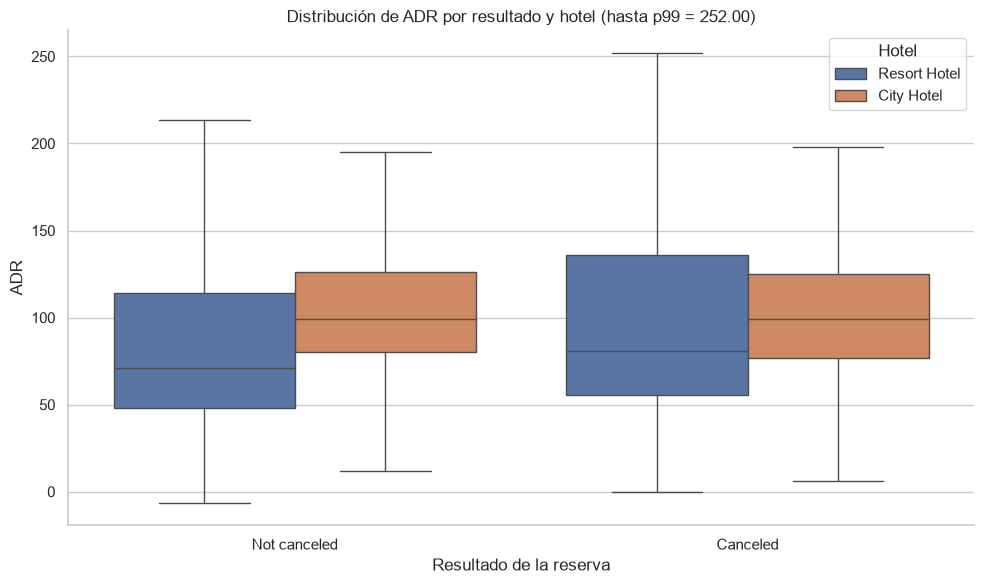

In [25]:
adr_visual_limit = adr_analysis_df["ADR"].quantile(0.99)
adr_plot_df = adr_analysis_df.loc[adr_analysis_df["ADR"].le(adr_visual_limit)].copy()
adr_plot_df["Reservation outcome"] = adr_plot_df["IsCanceled"].map(
    {0: "Not canceled", 1: "Canceled"}
)

figure, axis = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=adr_plot_df,
    x="Reservation outcome",
    y="ADR",
    hue="HotelType",
    showfliers=False,
    ax=axis,
)
axis.set_title(f"Distribución de ADR por resultado y hotel (hasta p99 = {adr_visual_limit:.2f})")
axis.set_xlabel("Resultado de la reserva")
axis.set_ylabel("ADR")
axis.legend(title="Hotel")
sns.despine(ax=axis)
figure.tight_layout()

if PROJECT_ROOT is not None:
    figures_dir = PROJECT_ROOT / "outputs" / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)
    adr_figure_path = figures_dir / "feature_analysis_adr_by_target_hotel.png"
    figure.savefig(adr_figure_path, dpi=300, bbox_inches="tight")
    print(f"Gráfica guardada en: {adr_figure_path}")

plt.show()

`ADR` no se considerará automáticamente segura sólo porque represente una tarifa habitual del negocio. Su procedencia transaccional impide garantizar que el valor del archivo sea el que estaba disponible al confirmar. El análisis cuantifica su comportamiento y la decisión final deberá incluir una comparación de validación con y sin esta feature.